#  Student Dropout Prediction — Logistic Regression

**Dataset:** `student_dropout_dataset_v3.csv`  
**Task:** Binary Classification — Prediksi apakah mahasiswa akan **Dropout (1)** atau **Tidak Dropout (0)**  
**Model:** Logistic Regression

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model (Overfitting / Underfitting)
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
# Install dependensi jika belum ada
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

print('Libraries loaded successfully ')

Libraries loaded successfully 


---
## 1.  Cara Melihat Tipe Data

Sebelum membangun model, kita perlu memahami struktur dataset:
- **`df.info()`** → Jumlah baris, kolom, tipe data setiap kolom, dan null values
- **`df.dtypes`** → Tipe data per kolom (int64, float64, object)
- **`df.describe()`** → Statistik deskriptif (mean, std, min, max) untuk numerik
- **`df.describe(include='object')`** → Statistik untuk kolom kategorik
- **`df.nunique()`** → Jumlah nilai unik per kolom
- **`df.isnull().sum()`** → Jumlah missing values per kolom

**Jenis tipe data:**
| Tipe | Arti | Contoh |
|------|------|--------|
| `int64` | Bilangan bulat | Age, Semester |
| `float64` | Bilangan desimal | GPA, CGPA, Study_Hours |
| `object` | Teks/Kategori | Gender, Department |
| `bool` | True/False | - |

In [3]:
# Load dataset
df = pd.read_csv('../student_dropout_dataset_v3.csv')

print('=' * 60)
print('SHAPE (Baris x Kolom):')
print(df.shape)

print('\n' + '=' * 60)
print('5 BARIS PERTAMA:')
df.head()

SHAPE (Baris x Kolom):
(10000, 19)

5 BARIS PERTAMA:


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [4]:
print('INFO DATASET (Tipe Data + Null Values):')
print('=' * 60)
df.info()

INFO DATASET (Tipe Data + Null Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA           

In [5]:
print('TIPE DATA PER KOLOM:')
print('=' * 60)
print(df.dtypes)

print('\nJUMLAH NILAI UNIK PER KOLOM:')
print(df.nunique())

print('\nMISSING VALUES:')
print(df.isnull().sum())

TIPE DATA PER KOLOM:
Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

JUMLAH NILAI UNIK PER KOLOM:
Student_ID               10000
Age                        115
Gender                       2
Family_Income             5438
Internet_Access              2
Study_Hours_per_Day        702
Attendance_Rate            444
Assignment_Delay_Days        9
Travel_Time_Minutes        589
Part_Time_Job                

In [6]:
print('STATISTIK DESKRIPTIF (Numerik):')
df.describe()

STATISTIK DESKRIPTIF (Numerik):


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [7]:
print('STATISTIK DESKRIPTIF (Kategorik):')
df.describe(include='object')

STATISTIK DESKRIPTIF (Kategorik):


,Gender,Internet_Access,Part_Time_Job,Scholarship,Semester,Department,Parental_Education
count,10000,10000,10000,10000,10000,10000,9489
unique,2,2,2,2,4,5,4
top,Female,Yes,No,No,Year 4,Science,Bachelor
freq,5011,8769,5996,6489,2536,2061,3949


DISTRIBUSI TARGET (Dropout):
Dropout
0    7646
1    2354
Name: count, dtype: int64

Persentase Dropout: 23.54%


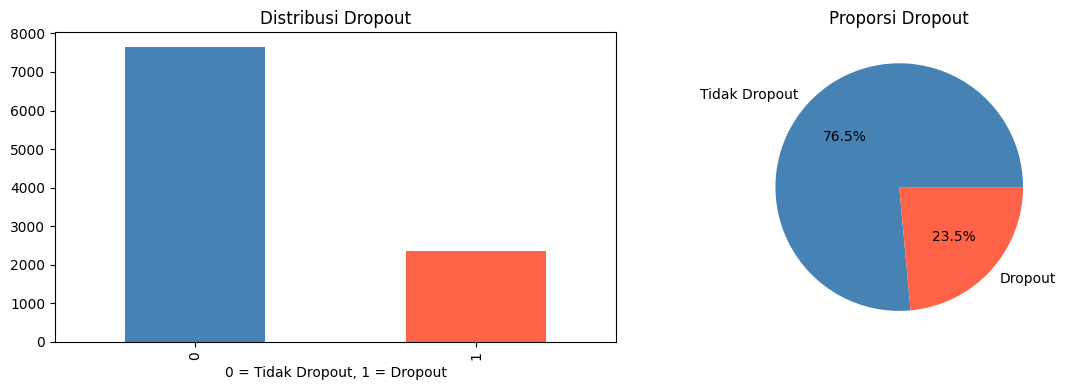

In [8]:
# Distribusi target variable
print('DISTRIBUSI TARGET (Dropout):')
print(df['Dropout'].value_counts())
print(f"\nPersentase Dropout: {df['Dropout'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Dropout'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Distribusi Dropout')
axes[0].set_xlabel('0 = Tidak Dropout, 1 = Dropout')
axes[1].pie(df['Dropout'].value_counts(), labels=['Tidak Dropout', 'Dropout'], autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Proporsi Dropout')
plt.tight_layout()
plt.show()

---
## 2.  Dataset Bisa Digunakan Untuk Apa

Dataset **Student Dropout** berisi informasi akademik, sosial-ekonomi, dan perilaku belajar mahasiswa. Dataset ini bisa digunakan untuk:

| No | Tujuan | Target | Jenis |
|----|--------|--------|-------|
| 1 | **Prediksi Dropout** | `Dropout` (0/1) | Classification |
| 2 | **Prediksi CGPA** | `CGPA` (nilai float) | Regression |
| 3 | **Prediksi Semester GPA** | `Semester_GPA` | Regression |
| 4 | **Analisis Faktor Dropout** | - | EDA / Feature Importance |
| 5 | **Early Warning System** | `Dropout` probabilitas | Classification |
| 6 | **Segmentasi Mahasiswa** | - | Clustering |

**Pada notebook ini:** Prediksi Dropout (Binary Classification)

---
## 3.  Model Yang Bisa Digunakan

### Untuk Classification (Prediksi Dropout):
| Model | Keunggulan | Kelemahan |
|-------|------------|----------|
| **Logistic Regression**  | Sederhana, interpretable, cepat | Linear boundary, sensitif outlier |
| Random Forest | Akurat, tahan overfitting | Kurang interpretable |
| XGBoost | Sangat akurat, fitur importance | Banyak hyperparameter |
| SVM | Efektif data kecil | Lambat data besar |
| Neural Network | Fleksibel, pola kompleks | Butuh data banyak, lambat |

**Logistic Regression** cocok ketika:
- Data relatif linear separable
- Butuh interpretasi koefisien
- Ingin probabilitas prediksi
- Baseline model sebelum model kompleks

In [9]:
# ============================================================
# PREPROCESSING
# ============================================================

# Identifikasi kolom
target_col = 'Dropout'
drop_cols = ['Student_ID']  # ID tidak berguna untuk prediksi
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in [target_col] + drop_cols]

print('Kolom Kategorik:', categorical_cols)
print('Kolom Numerik:', numerical_cols)

Kolom Kategorik: ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']
Kolom Numerik: ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']


In [10]:
# Encode kolom kategorik
df_processed = df.drop(columns=drop_cols).copy()

le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

# Pisahkan fitur dan target
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

print('Ukuran X:', X.shape)
print('Ukuran y:', y.shape)
print('Distribusi y:')
print(y.value_counts())

Ukuran X: (10000, 17)
Ukuran y: (10000,)
Distribusi y:
Dropout
0    7646
1    2354
Name: count, dtype: int64


In [11]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% untuk testing
    random_state=42,         # Reproduktibilitas
    stratify=y               # Jaga proporsi kelas
)

print(f'Training set: {X_train.shape[0]} baris')
print(f'Test set    : {X_test.shape[0]} baris')

Training set: 8000 baris
Test set    : 2000 baris


In [12]:
# Imputasi nilai null dengan median (dataset mengandung NaN di beberapa kolom)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Scaling fitur (PENTING untuk Logistic Regression!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print('Imputation + Scaling selesai ')

Imputation + Scaling selesai 


---
## 4.  Parameter Yang Bisa Diubah / Disetel

### LogisticRegression() — Parameter Utama:

| Parameter | Default | Penjelasan | Nilai Umum |
|-----------|---------|------------|------------|
| `C` | 1.0 | **Inverse regularization strength.** Nilai kecil = regularisasi kuat (cegah overfitting). Nilai besar = regularisasi lemah. | `0.001`, `0.01`, `0.1`, `1`, `10`, `100` |
| `penalty` | `'l2'` | Jenis regularisasi. `'l1'` bisa zero-out fitur (feature selection), `'l2'` shrink semua koefisien | `'l1'`, `'l2'`, `'elasticnet'`, `'none'` |
| `solver` | `'lbfgs'` | Algoritma optimasi. `'liblinear'` cocok untuk data kecil + L1, `'saga'` untuk dataset besar | `'lbfgs'`, `'liblinear'`, `'saga'`, `'sag'` |
| `max_iter` | 100 | Maksimum iterasi sampai konvergen | `100`, `500`, `1000` |
| `class_weight` | `None` | Gunakan `'balanced'` jika data *imbalanced* | `None`, `'balanced'` |
| `random_state` | `None` | Seed untuk reproduktibilitas | angka integer |
| `multi_class` | `'auto'` | Untuk multi-class: `'ovr'` atau `'multinomial'` | `'auto'`, `'ovr'`, `'multinomial'` |

In [13]:
# ============================================================
# BANGUN MODEL LOGISTIC REGRESSION
# ============================================================

model = LogisticRegression(
    C=1.0,                   # Regularisasi inverse (coba ubah: 0.01, 0.1, 1, 10)
    penalty='l2',            # Tipe regularisasi ('l1' atau 'l2')
    solver='lbfgs',          # Optimizer
    max_iter=1000,           # Iterasi maksimum
    class_weight='balanced', # Tangani imbalanced class
    random_state=42
)

# Training model
model.fit(X_train_scaled, y_train)
print('Model berhasil ditraining ')

Model berhasil ditraining 


In [14]:
# Prediksi
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probabilitas kelas 1 (Dropout)

print('Contoh prediksi 10 data pertama:')
print('Prediksi :', y_pred[:10])
print('Aktual   :', y_test.values[:10])
print('Prob Drop:', np.round(y_pred_proba[:10], 3))

Contoh prediksi 10 data pertama:
Prediksi : [0 1 0 1 1 0 0 1 1 1]
Aktual   : [0 0 0 0 1 0 0 0 0 0]
Prob Drop: [0.314 0.501 0.27  0.551 0.731 0.182 0.065 0.575 0.628 0.605]


---
## 5.  Evaluasi Yang Dipakai

### Metrik Classification:

| Metrik | Formula | Penjelasan |
|--------|---------|------------|
| **Accuracy** | TP+TN / Total | Berapa % prediksi benar secara keseluruhan |
| **Precision** | TP / (TP+FP) | Dari yang diprediksi dropout, berapa yang benar dropout |
| **Recall** | TP / (TP+FN) | Dari yang benar dropout, berapa yang berhasil ditangkap |
| **F1-Score** | 2×(P×R)/(P+R) | Harmonic mean Precision & Recall |
| **ROC-AUC** | Area under ROC | Kemampuan model membedakan kelas (0.5 = random, 1.0 = sempurna) |
| **Confusion Matrix** | - | Tabel TP, TN, FP, FN |

**TP** = True Positive (prediksi dropout, benar dropout)  
**TN** = True Negative (prediksi tidak dropout, benar tidak)  
**FP** = False Positive (prediksi dropout, padahal tidak) — False Alarm  
**FN** = False Negative (prediksi tidak dropout, padahal dropout) — Miss

In [15]:
# ============================================================
# EVALUASI MODEL
# ============================================================

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print('=' * 50)
print('HASIL EVALUASI MODEL')
print('=' * 50)
print(f'Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(f'ROC-AUC   : {auc:.4f}')

print('\n' + '=' * 50)
print('CLASSIFICATION REPORT:')
print(classification_report(y_test, y_pred, target_names=['Tidak Dropout', 'Dropout']))

HASIL EVALUASI MODEL
Accuracy  : 0.7440 (74.40%)
Precision : 0.4732
Recall    : 0.7686
F1-Score  : 0.5858
ROC-AUC   : 0.8206

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

Tidak Dropout       0.91      0.74      0.81      1529
      Dropout       0.47      0.77      0.59       471

     accuracy                           0.74      2000
    macro avg       0.69      0.75      0.70      2000
 weighted avg       0.81      0.74      0.76      2000



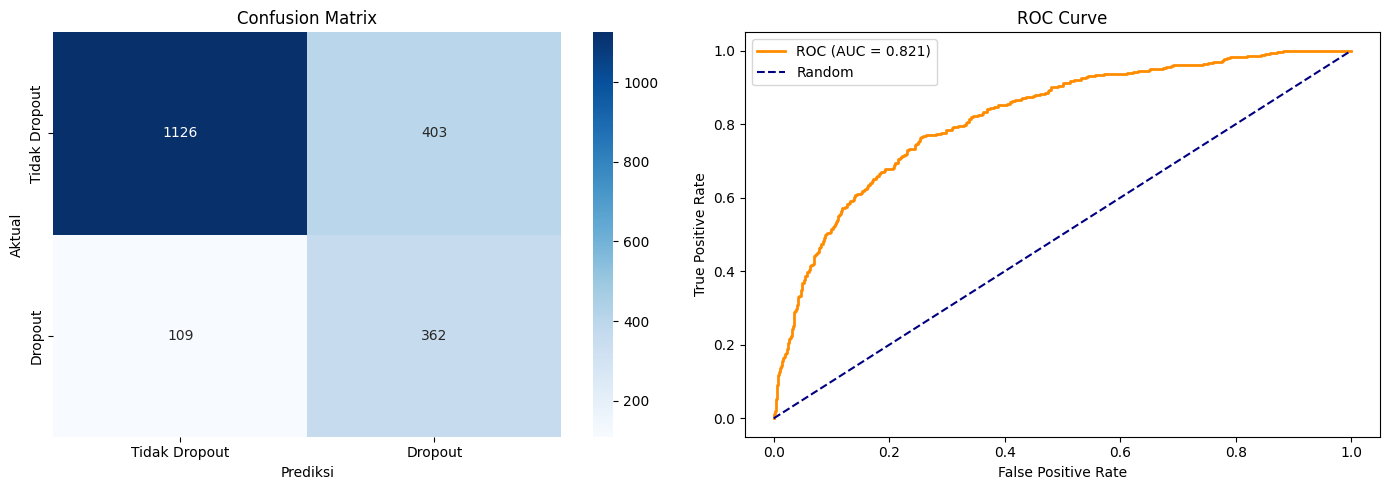

In [16]:
# Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Dropout', 'Dropout'],
            yticklabels=['Tidak Dropout', 'Dropout'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cross-validation untuk estimasi yang lebih robust
# Impute NaN dulu sebelum scaling (X masih mengandung missing values)
from sklearn.pipeline import Pipeline
cv_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_cv = cv_pipe.fit_transform(X)

cv_scores = cross_val_score(model, X_cv, y, cv=5, scoring='roc_auc')

print('Cross-Validation ROC-AUC (5-Fold):')
print(f'  Setiap fold : {cv_scores.round(4)}')
print(f'  Mean        : {cv_scores.mean():.4f}')
print(f'  Std         : {cv_scores.std():.4f}')

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py", line 1247, in fit
    X, y = validate_data(
  File "/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py", line 2971,

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### Panduan Interpretasi:

#### Accuracy:
| Range | Interpretasi |
|-------|-------------|
| < 60% | Sangat Buruk |
| 60–70% | Cukup |
| 70–80% | Baik |
| 80–90% | Sangat Baik |
| > 90% | Luar Biasa (waspadai overfitting) |

#### ROC-AUC:
| Range | Interpretasi |
|-------|-------------|
| 0.5 | Sama seperti acak (buruk) |
| 0.6–0.7 | Cukup |
| 0.7–0.8 | Baik |
| 0.8–0.9 | Sangat Baik |
| > 0.9 | Luar Biasa |

#### Precision vs Recall:
- **Prioritas Recall** → Jika salah prediksi dropout sangat mahal (lebih baik false alarm daripada miss)
- **Prioritas Precision** → Jika intervensi mahal, hindari false alarm
- **F1-Score** → Seimbang antara Precision dan Recall

####  Waspada Imbalanced Data:
- Accuracy bisa menyesatkan! Jika 90% data tidak dropout, model yang selalu prediksi 'tidak dropout' dapat accuracy 90%
- Gunakan **F1-Score** dan **ROC-AUC** sebagai metrik utama untuk imbalanced data

####  Cek Overfitting:
```
Train Accuracy >> Test Accuracy  → OVERFITTING
Train Accuracy ≈ Test Accuracy   → Baik
Train Accuracy ≈ Test Accuracy (keduanya rendah) → UNDERFITTING
```

In [ ]:
# Cek train vs test untuk deteksi overfitting
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, y_pred)

print('DETEKSI OVERFITTING:')
print(f'  Train Accuracy: {train_acc:.4f}')
print(f'  Test  Accuracy: {test_acc:.4f}')
print(f'  Selisih       : {abs(train_acc - test_acc):.4f}')

if abs(train_acc - test_acc) > 0.05:
    print('    Selisih > 5%, kemungkinan OVERFITTING!')
else:
    print('    Selisih kecil, model terlihat stabil')

# Feature importances (koefisien logistic regression)
print('\nPENTINGNYA FITUR (Koefisien Logistic Regression):')
feat_imp = pd.Series(np.abs(model.coef_[0]), index=X.columns).sort_values(ascending=False)
print(feat_imp.head(10))

---
## 7.  Cara Mengoptimasi Model

### Strategi Optimasi:

#### A. Jika Model UNDERFITTING (akurasi rendah di train dan test):
- Naikkan `C` (kurangi regularisasi)
- Tambah fitur baru (feature engineering)
- Gunakan model yang lebih kompleks (Random Forest, XGBoost)
- Tambah interaksi fitur

#### B. Jika Model OVERFITTING (akurasi train >> test):
- Turunkan `C` (perkuat regularisasi)
- Gunakan `penalty='l1'` untuk feature selection
- Tambahkan lebih banyak data training
- Hapus fitur yang tidak relevan

#### C. Jika Data IMBALANCED:
- Gunakan `class_weight='balanced'`
- Oversampling (SMOTE)
- Undersampling
- Gunakan `threshold` berbeda saat prediksi

#### D. Hyperparameter Tuning dengan GridSearchCV:

In [ ]:
# Hyperparameter Tuning dengan GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # Regularisasi
    'penalty': ['l1', 'l2'],                # Jenis regularisasi
    'solver': ['liblinear'],                # Solver yang support L1
    'class_weight': [None, 'balanced']      # Handle imbalanced
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',   # Metrik untuk memilih model terbaik
    n_jobs=-1,           # Gunakan semua CPU
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print('\n HYPERPARAMETER TERBAIK:')
print(grid_search.best_params_)
print(f'\nROC-AUC Terbaik (CV): {grid_search.best_score_:.4f}')

In [ ]:
# Evaluasi model terbaik dari GridSearch
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

print('HASIL MODEL SETELAH TUNING:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred_best):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}')

---
## 8.  Cara Menyimpan Model

Ada dua cara umum menyimpan model:

1. **`joblib`** → Lebih efisien untuk objek NumPy besar (direkomendasikan untuk scikit-learn)
2. **`pickle`** → Library standar Python

Yang perlu disimpan:
- **Model** itu sendiri
- **Scaler** (karena test data harus di-scale dengan scaler yang sama seperti saat training!)
- **Encoder** (jika ada LabelEncoder)
- Metadata: kolom yang digunakan

In [ ]:
import joblib
import os

# Buat folder untuk menyimpan model
os.makedirs('saved_models', exist_ok=True)

# Simpan model utama
joblib.dump(best_model, 'saved_models/logistic_regression_dropout.pkl')
print(' Model disimpan: saved_models/logistic_regression_dropout.pkl')

# Simpan scaler (WAJIB disimpan!)
joblib.dump(scaler, 'saved_models/scaler_dropout.pkl')
print(' Scaler disimpan: saved_models/scaler_dropout.pkl')

# Simpan daftar kolom fitur
feature_columns = list(X.columns)
joblib.dump(feature_columns, 'saved_models/feature_columns_dropout.pkl')
print(' Feature columns disimpan')

print(f'\n File yang disimpan di folder saved_models/:')
for f in os.listdir('saved_models'):
    fpath = os.path.join('saved_models', f)
    print(f'   {f} ({os.path.getsize(fpath)} bytes)')

---
## 9.  Cara Menggunakan Model Hasil Training

Setelah model disimpan, cara menggunakannya untuk prediksi data baru:

**Alur:** Data Baru → Preprocessing (encode + scale) → Model → Prediksi

 **PENTING:** Gunakan scaler yang SAMA persis dengan yang dipakai saat training! Jangan fit scaler baru pada data baru.

In [ ]:
# ============================================================
# SIMULASI: Menggunakan model untuk prediksi data baru
# ============================================================

# Load model dan scaler yang sudah disimpan
loaded_model = joblib.load('saved_models/logistic_regression_dropout.pkl')
loaded_scaler = joblib.load('saved_models/scaler_dropout.pkl')
loaded_columns = joblib.load('saved_models/feature_columns_dropout.pkl')

print('Model dan scaler berhasil dimuat ')
print(f'Fitur yang diharapkan: {loaded_columns}')

In [ ]:
# Buat data mahasiswa baru (contoh 3 mahasiswa)
# Kolom harus sama persis dengan saat training!
new_students = pd.DataFrame({
    'Age': [20, 22, 19],
    'Gender': [1, 0, 1],              # 0/1 setelah LabelEncode
    'Family_Income': [30000, 15000, 50000],
    'Internet_Access': [1, 0, 1],     # 1=Yes, 0=No
    'Study_Hours_per_Day': [4.0, 1.5, 6.0],
    'Attendance_Rate': [85, 55, 92],
    'Assignment_Delay_Days': [1, 7, 0],
    'Travel_Time_Minutes': [20, 60, 15],
    'Part_Time_Job': [0, 1, 0],       # 0=No, 1=Yes
    'Scholarship': [1, 0, 1],
    'Stress_Index': [4, 8, 3],
    'GPA': [3.2, 1.8, 3.7],
    'Semester_GPA': [3.1, 1.6, 3.8],
    'CGPA': [3.0, 1.7, 3.6],
    'Semester': [3, 5, 2],
    'Department': [0, 2, 1],          # Setelah LabelEncode
    'Parental_Education': [2, 0, 3],  # Setelah LabelEncode
})

# Pastikan kolom sesuai urutan yang benar
new_students = new_students[loaded_columns]

# Scale data baru menggunakan scaler yang sudah disimpan
new_students_scaled = loaded_scaler.transform(new_students)

# Prediksi
predictions = loaded_model.predict(new_students_scaled)
probabilities = loaded_model.predict_proba(new_students_scaled)

print('\nHASIL PREDIKSI:')
print('=' * 55)
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    status = ' DROPOUT' if pred == 1 else ' TIDAK DROPOUT'
    print(f'Mahasiswa {i+1}: {status}')
    print(f'  Probabilitas Tidak Dropout : {prob[0]:.2%}')
    print(f'  Probabilitas Dropout       : {prob[1]:.2%}')
    print()

In [ ]:
# Custom threshold: Jika ingin lebih peka terhadap dropout
# Default threshold = 0.5, tapi bisa diturunkan
threshold = 0.4  # Lebih sensitif mendeteksi dropout

custom_preds = (probabilities[:, 1] >= threshold).astype(int)

print(f'Prediksi dengan threshold={threshold}:')
for i, (pred, prob) in enumerate(zip(custom_preds, probabilities)):
    status = ' BERISIKO DROPOUT' if pred == 1 else ' AMAN'
    print(f'Mahasiswa {i+1}: {status} (prob={prob[1]:.2%})')

print('\n Selesai! Model berhasil digunakan untuk prediksi.')